<a href="https://colab.research.google.com/github/sofiautrera-cpu/Tareas/blob/main/Simulaci%C3%B3n_del_Examen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación Examen Unidad / Simulación del Examen (Core)
- Duration: No limit
- Deadline: N\A
- Description
- Simulación del Examen (Core)

# Fundamentos de Data Science – Práctica para el Examen

# Contexto:
- La tarea es limpiar y explorar los datos para una compañía de tecnología emergente que desarrolla aplicaciones móviles.
- La empresa quiere mejorar la experiencia del usuario y aumentar la retención de usuarios en sus aplicaciones.
- Han recolectado datos sobre el uso de sus aplicaciones y quieren entender mejor cómo los usuarios interactúan con sus productos.



Requisitos

1) Limpieza de Datos:

- El primer paso en este proceso es usar Python para limpiar los datos y dejarlos listos para el análisis.
- Deben:

- Identificar y abordar cualquier valor duplicado.
- Identificar y abordar cualquier dato que falte en este conjunto de datos.
- Trátenlos de forma adecuada.
- Incluyan una breve descripción en el método que usan para tratar con los valores que faltan junto con una justificación para el uso de ese método.
- Asegurarse de que todas las columnas coincidan con los tipos de datos enumerados en el diccionario de datos.
- Identificar y abordar cualquier inconsistencia en los valores categóricos (ejemplo: android, Android, ANDROID).
- Identificar y abordar cualquier punto de datos inapropiados o inusuales (ejemplo: tiempo de uso de 10000 horas en una semana).




In [1]:
# Codigo para generar los datos

import pandas as pd
import numpy as np
import random

# Configuramos la semilla para reproducibilidad
np.random.seed(42)

# Generamos los datos sintéticos
user_id = range(1, 301)
app_version = np.random.choice(['1.0', '1.1', '1.2', '1.3'], 300)
platform = np.random.choice(['Android', 'iOS'], 300)
session_duration = np.random.randint(1, 180, 300)
number_of_sessions = np.random.randint(1, 20, 300)
country = np.random.choice(['USA', 'Canada', 'Mexico', 'UK', 'Germany', 'France', 'Spain', 'Italy'], 300)
user_feedback = np.random.randint(1, 6, 300)

# Creamos el DataFrame
data = pd.DataFrame({
    'user_id': user_id,
    'app_version': app_version,
    'platform': platform,
    'session_duration': session_duration,
    'number_of_sessions': number_of_sessions,
    'country': country,
    'user_feedback': user_feedback
})

# Guardamos los datos en un archivo CSV
data.to_csv('user_app_data.csv', index=False)
print("Datos generados y guardados en 'user_app_data.csv'")

Datos generados y guardados en 'user_app_data.csv'


In [4]:
print(data.head())

   user_id app_version platform  session_duration  number_of_sessions country  \
0        1         1.2  Android               109                  11  France   
1        2         1.3  Android               116                  17      UK   
2        3         1.0  Android                94                  13  France   
3        4         1.2      iOS                47                   1  Canada   
4        5         1.2      iOS                99                   2  Canada   

   user_feedback  
0              1  
1              2  
2              5  
3              4  
4              3  


In [7]:
# 1. Limpieza de Datos: Identificar y abordar valores duplicados

# Identificar filas duplicadas
duplicates = data.duplicated().sum()
print(f"Número de filas duplicadas encontradas: {duplicates}")

# Si hay duplicados, se pueden abordar de varias maneras. Una común es eliminarlos.
# Por simplicidad y dado que los datos son sintéticos, los eliminaremos.
if duplicates > 0:
    data.drop_duplicates(inplace=True)
    print("Filas duplicadas eliminadas.")
    print(f"Número de filas después de eliminar duplicados: {len(data)}")
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas encontradas: 0
No se encontraron filas duplicadas.


In [9]:
# 1. Limpieza de Datos: Identificar y abordar datos que faltan

# Identificar valores faltantes
missing_values = data.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values)

# Justificación del método para tratar valores faltantes:
# En este caso, dado que los datos son sintéticos y no se especificó un comportamiento para valores nulos al generarlos,
# es poco probable que haya valores faltantes. Sin embargo, en un conjunto de datos real, la estrategia dependería de la naturaleza de los datos y el contexto:
# 1. Eliminación de filas: Si el número de valores faltantes es pequeño y no sesga el conjunto de datos.
# 2. Imputación con la media/mediana: Para datos numéricos, cuando la distribución es conocida y la imputación no introduce un sesgo significativo.
# 3. Imputación con la moda: Para datos categóricos.
# 4. Imputación basada en modelos: Usando algoritmos de Machine Learning para predecir los valores faltantes.

# Para este ejercicio, asumiremos que si hay valores faltantes, los eliminaremos si son pocos, para mantener la integridad de las filas existentes.
# Si hubiera muchos, se consideraría una imputación más sofisticada.

# Contar el total de valores faltantes
total_missing = missing_values.sum()

if total_missing > 0:
    print(f"\nSe encontraron {total_missing} valores faltantes en el dataset. Procediendo a eliminarlos.")
    data.dropna(inplace=True)
    print("Valores faltantes eliminados.")
    print(f"Número de filas después de eliminar valores faltantes: {len(data)}")
else:
    print("\nNo se encontraron valores faltantes.")

Valores faltantes por columna:
user_id               0
app_version           0
platform              0
session_duration      0
number_of_sessions    0
country               0
user_feedback         0
dtype: int64

No se encontraron valores faltantes.


In [11]:
# 1. Limpieza de Datos: Asegurarse de que todas las columnas coincidan con los tipos de datos.

print("Tipos de datos actuales:")
print(data.dtypes)

# Definir los tipos de datos esperados según el diccionario de datos
expected_dtypes = {
    'user_id': 'int64',
    'app_version': 'object', # o 'category' si se prefiere
    'platform': 'object',    # o 'category'
    'session_duration': 'int64',
    'number_of_sessions': 'int64',
    'country': 'object',     # o 'category'
    'user_feedback': 'int64'
}

print("\nTipos de datos esperados:")
for col, dtype in expected_dtypes.items():
    print(f"{col}: {dtype}")

# Convertir columnas a los tipos de datos esperados si no coinciden
for col, expected_dtype in expected_dtypes.items():
    if data[col].dtype != expected_dtype:
        try:
            data[col] = data[col].astype(expected_dtype)
            print(f"Columna '{col}' convertida a {expected_dtype}")
        except Exception as e:
            print(f"Error al convertir la columna '{col}' a {expected_dtype}: {e}")
    else:
        print(f"Columna '{col}' ya es de tipo {expected_dtype}")

print("\nTipos de datos después de la verificación y conversión:")
print(data.dtypes)

Tipos de datos actuales:
user_id                int64
app_version           object
platform              object
session_duration       int64
number_of_sessions     int64
country               object
user_feedback          int64
dtype: object

Tipos de datos esperados:
user_id: int64
app_version: object
platform: object
session_duration: int64
number_of_sessions: int64
country: object
user_feedback: int64
Columna 'user_id' ya es de tipo int64
Columna 'app_version' ya es de tipo object
Columna 'platform' ya es de tipo object
Columna 'session_duration' ya es de tipo int64
Columna 'number_of_sessions' ya es de tipo int64
Columna 'country' ya es de tipo object
Columna 'user_feedback' ya es de tipo int64

Tipos de datos después de la verificación y conversión:
user_id                int64
app_version           object
platform              object
session_duration       int64
number_of_sessions     int64
country               object
user_feedback          int64
dtype: object


In [15]:
# 1. Limpieza de Datos: Identificar y abordar inconsistencias en los valores categóricos

# Estandarizar la columna 'platform'
print("Valores únicos en 'platform' antes de la estandarización:")
print(data['platform'].unique())
data['platform'] = data['platform'].str.lower()
print("Valores únicos en 'platform' después de la estandarización:")
print(data['platform'].unique())

# Estandarizar la columna 'country'
print("\nValores únicos en 'country' antes de la estandarización:")
print(data['country'].unique())
data['country'] = data['country'].str.lower()
print("Valores únicos en 'country' después de la estandarización:")
print(data['country'].unique())

# Convertir las columnas categóricas a tipo 'category' para optimizar el uso de memoria
data['platform'] = data['platform'].astype('category')
data['country'] = data['country'].astype('category')
print("\nColumnas 'platform' y 'country' convertidas a tipo 'category'.")
print(data.dtypes)

Valores únicos en 'platform' antes de la estandarización:
['android', 'ios']
Categories (2, object): ['android', 'ios']
Valores únicos en 'platform' después de la estandarización:
['android' 'ios']

Valores únicos en 'country' antes de la estandarización:
['france', 'uk', 'canada', 'germany', 'mexico', 'usa', 'spain', 'italy']
Categories (8, object): ['canada', 'france', 'germany', 'italy', 'mexico', 'spain', 'uk', 'usa']
Valores únicos en 'country' después de la estandarización:
['france' 'uk' 'canada' 'germany' 'mexico' 'usa' 'spain' 'italy']

Columnas 'platform' y 'country' convertidas a tipo 'category'.
user_id                  int64
app_version             object
platform              category
session_duration         int64
number_of_sessions       int64
country               category
user_feedback            int64
dtype: object


In [20]:
# 1. Limpieza de Datos: Identificar y abordar puntos de datos inapropiados o inusuales

# Revisar 'session_duration' (duración de sesión en minutos)
# Un ejemplo dado fue 'tiempo de uso de 10000 horas en una semana'.
# 10000 horas * 60 minutos/hora = 600,000 minutos. Esto es claramente un valor extremo.
# Aunque nuestros datos sintéticos van hasta 180 minutos, vamos a definir un umbral razonable.
# Consideremos que una sesión no debería exceder, por ejemplo, 240 minutos (4 horas).

unusual_session_duration = data[data['session_duration'] > 240]
print(f"\nFilas con 'session_duration' inusualmente alta (más de 240 minutos):\n{unusual_session_duration}")

if not unusual_session_duration.empty:
    print("Se encontraron sesiones con duraciones inusualmente altas. Se podrían investigar o eliminar.")
    # Para este ejercicio, asumiremos que se eliminarán las filas con duraciones excesivas.
    data = data[data['session_duration'] <= 240]
    print("Filas con 'session_duration' > 240 minutos eliminadas.")
else:
    print("No se encontraron sesiones con duraciones inusualmente altas.")

# Revisar 'number_of_sessions' (número de sesiones en un día)
# Una persona podría abrir y cerrar una app varias veces, pero un número excesivamente alto podría ser anómalo.
# Consideremos un máximo razonable, por ejemplo, 50 sesiones en un día.

unusual_number_of_sessions = data[data['number_of_sessions'] > 50]
print(f"\nFilas con 'number_of_sessions' inusualmente alto (más de 50):\n{unusual_number_of_sessions}")

if not unusual_number_of_sessions.empty:
    print("Se encontraron usuarios con un número inusualmente alto de sesiones. Se podrían investigar o eliminar.")
    # Para este ejercicio, asumiremos que se eliminarán las filas con número de sesiones excesivas.
    data = data[data['number_of_sessions'] <= 50]
    print("Filas con 'number_of_sessions' > 50 eliminadas.")
else:
    print("No se encontraron usuarios con un número inusualmente alto de sesiones.")

# Revisar 'user_feedback' (puntuación de 1-5)
# Asegurarnos de que todos los valores estén dentro del rango [1, 5].

invalid_user_feedback = data[(data['user_feedback'] < 1) | (data['user_feedback'] > 5)]
print(f"\nFilas con 'user_feedback' fuera del rango (1-5):\n{invalid_user_feedback}")

if not invalid_user_feedback.empty:
    print("Se encontraron valores de 'user_feedback' fuera del rango esperado. Se podrían investigar o eliminar.")
    # Para este ejercicio, asumiremos que se eliminarán las filas con feedback inválido.
    data = data[(data['user_feedback'] >= 1) & (data['user_feedback'] <= 5)]
    print("Filas con 'user_feedback' fuera de rango eliminadas.")
else:
    print("No se encontraron valores de 'user_feedback' fuera del rango esperado.")

print(f"\nDimensiones finales del DataFrame después de la limpieza: {data.shape}")


Filas con 'session_duration' inusualmente alta (más de 240 minutos):
Empty DataFrame
Columns: [user_id, app_version, platform, session_duration, number_of_sessions, country, user_feedback]
Index: []
No se encontraron sesiones con duraciones inusualmente altas.

Filas con 'number_of_sessions' inusualmente alto (más de 50):
Empty DataFrame
Columns: [user_id, app_version, platform, session_duration, number_of_sessions, country, user_feedback]
Index: []
No se encontraron usuarios con un número inusualmente alto de sesiones.

Filas con 'user_feedback' fuera del rango (1-5):
Empty DataFrame
Columns: [user_id, app_version, platform, session_duration, number_of_sessions, country, user_feedback]
Index: []
No se encontraron valores de 'user_feedback' fuera del rango esperado.

Dimensiones finales del DataFrame después de la limpieza: (300, 7)


2) Exploración de Datos:

El siguiente paso es completar una exploración de los datos usando Python. Esto debe incluir:






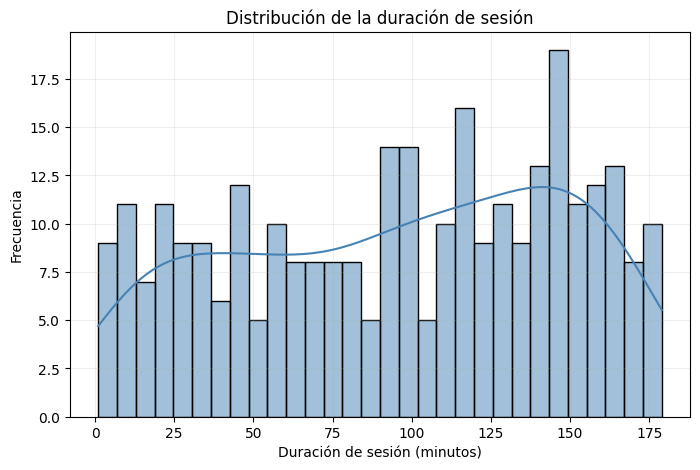

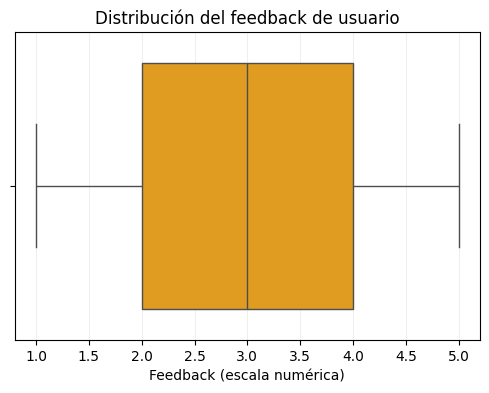

In [25]:
# Dos tipos diferentes de visualizaciones exploratorias univariantes.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.

import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 1: Histograma de duración de sesión (session_duration)
def plot_session_duration_hist(df):
    plt.figure(figsize=(8,5))
    sns.histplot(df["session_duration"], bins=30, kde=True, color="steelblue")
    plt.title("Distribución de la duración de sesión")
    plt.xlabel("Duración de sesión (minutos)") # Changed to minutes as per data description
    plt.ylabel("Frecuencia")
    plt.grid(alpha=0.2)
    plt.show()

    # Interpretación:
    # Este histograma permite observar la distribución general del tiempo de uso.
    # Si la curva se sesga hacia la derecha, indica que la mayoría de los usuarios
    # tiene sesiones cortas y solo unos pocos presentan sesiones muy largas.

# Visualización 2: Boxplot de feedback de usuario (user_feedback)
def plot_user_feedback_box(df):
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df["user_feedback"], color="orange")
    plt.title("Distribución del feedback de usuario")
    plt.xlabel("Feedback (escala numérica)")
    plt.grid(axis="x", alpha=0.2)
    plt.show()

    # Interpretación:
    # El boxplot permite identificar la mediana, la dispersión y posibles outliers.
    # Si aparecen valores extremos, pueden representar usuarios muy insatisfechos
    # o extremadamente satisfechos, lo que es útil para análisis de experiencia.

# Código modular
plot_session_duration_hist(data)
plot_user_feedback_box(data)

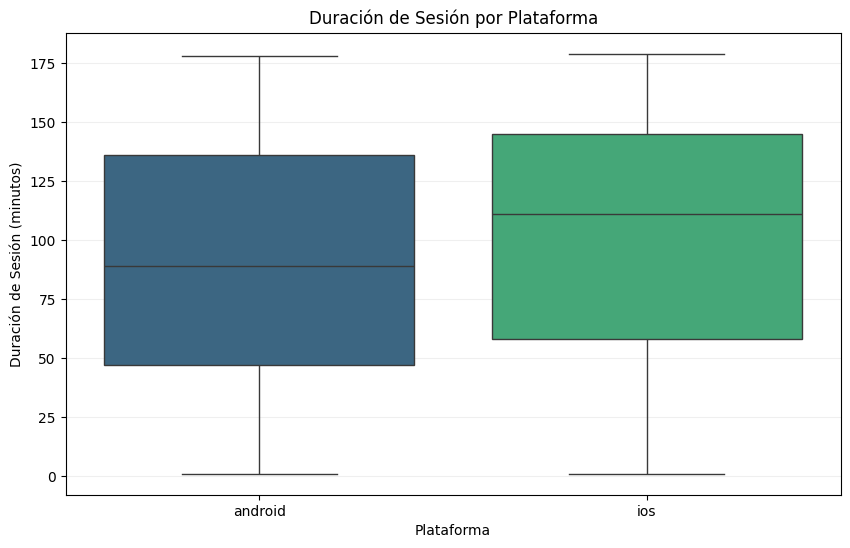

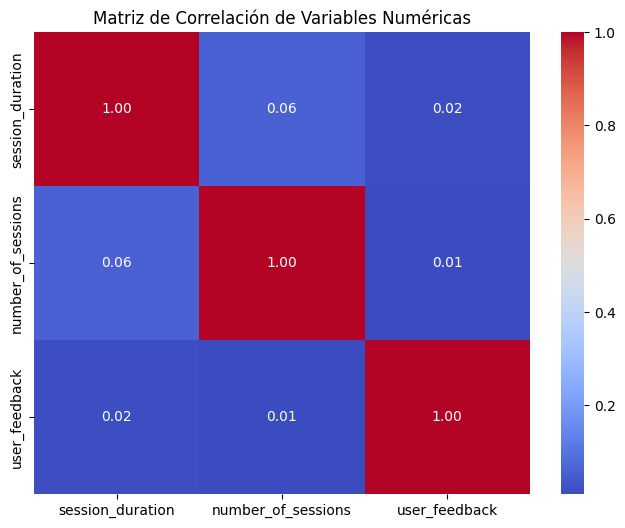

In [26]:
# 2) Exploración de Datos:
# Dos tipos diferentes de visualizaciones exploratorias multivariantes. Cada visualización debe incluir una breve interpretación dentro del archivo de código.Dos tipos diferentes de visualizaciones exploratorias multivariantes.

import matplotlib.pyplot as plt
import seaborn as sns

# Visualización 1: Boxplot de session_duration por platform
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='session_duration', data=data, hue='platform', palette='viridis', legend=False)
plt.title('Duración de Sesión por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Duración de Sesión (minutos)')
plt.grid(axis='y', alpha=0.2)
plt.show()

# Interpretación:
# Este boxplot permite comparar la distribución de la duración de las sesiones entre diferentes plataformas (Android vs. iOS).
# Podemos observar si una plataforma tiende a tener sesiones más largas o más cortas en promedio, y si hay más variabilidad o valores atípicos en alguna de ellas.
# Por ejemplo, si una mediana es significativamente más alta, sugiere un mayor engagement o uso prolongado en esa plataforma.

# Visualización 2: Heatmap de correlación entre variables numéricas
# Seleccionamos solo las columnas numéricas relevantes para la correlación
numeric_cols = data[['session_duration', 'number_of_sessions', 'user_feedback']]
correlation_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Interpretación:
# El heatmap de correlación nos ayuda a visualizar la fuerza y dirección de la relación lineal entre pares de variables numéricas.
# Valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente, mientras que valores cercanos a 0 indican poca o ninguna correlación lineal.
# Esto es útil para identificar qué factores numéricos podrían estar influyendo mutuamente en el comportamiento del usuario.

 # Diccionario de Datos
- user_id: Identificación única del usuario.
- app_version: Versión de la aplicación usada.
- platform: Plataforma del dispositivo (Android, iOS).
- session_duration: Duración de la sesión en minutos.
- number_of_sessions: Número de sesiones en un día.
- country: País del usuario.
- user_feedback: Puntuación de la experiencia del usuario (1-5).